# Instalação e Importação de bibliotecas

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas

In [ ]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print("Verificando GPU disponível:", torch.cuda.is_available())

Verificando GPU disponível: True


# Carregando o Dataset

 O Dataset usado é o [RePro: A Benchmark Dataset for Opinion Mining for Brazilian Portuguese](https://github.com/lucasnil/repro), que será carregado pelo Hugging Face.

In [ ]:
try:
    dataset_repro = load_dataset("lucasnil/repro")
    df_raw = pd.DataFrame(dataset_repro['train'])
except Exception as e:
    print(f"Erro ao carregar do HF")

print(f"Dataset original carregado com {len(df_raw)} instâncias.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.39k [00:00<?, ?B/s]

RePro.csv:   0%|          | 0.00/4.33M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Dataset original carregado com 10003 instâncias.


In [ ]:
df_raw.head(10)

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,review_text,overall_rating,...,reviewer_gender,reviewer_state,topics,polarity,ENTREGA,OUTROS,PRODUTO,CONDICOESDERECEBIMENTO,INADEQUADA,ANUNCIO
0,2018-05-14 13:57:59,a4380c38e7e73687066bf66329454b33e7749a8b49ad1a...,34398895,Kit Com 10 Cuecas Boxer de Cotton 4.0 - Polo M...,None,Moda,Masculino,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...",3,...,M,SP,"['ENTREGA', 'OUTROS']","['NEGATIVO', 'POSITIVO']",1,1,0,0,0,0
1,2018-01-18 12:02:42,fbf1d015682ddd45f97cedbc935fd42e42325498e68cd4...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,None,Celulares e Smartphones,Smartphone,"""compra sem susto""","Aparelho muito bom, confiável e com valor aqui...",4,...,M,ES,['PRODUTO'],['POSITIVO'],0,0,1,0,0,0
2,2018-04-18 12:06:14,6042f06b0d63fd46499b2f6eed116df96cc8f2649df8f3...,132710805,Impressora Hp Sprocket 100 Jato de Tinta,None,Câmeras e Filmadoras,Impressora e Papel Fotográfico,*,"As cores da impressão não são fiéis, O custo b...",3,...,F,MG,['PRODUTO'],['NEGATIVO'],0,0,1,0,0,0
3,2018-01-23 08:11:11,4871f745136a74808a49970db18d205fd66cb666acabb2...,119882282,Livro - It: A Coisa,None,Livros,Literatura Estrangeira,***,"A história é muito boa, porém o autor ""enrolou...",3,...,F,MG,['PRODUTO'],"['NEGATIVO', 'POSITIVO']",0,0,1,0,0,0
4,2018-02-17 11:19:38,6141e659c620ab597a5cda1b9150e180f7337434260eee...,23218825,Termometro Laser Digital Infravermelho Febre D...,None,Bebês,Higiene e Saúde,****,"Entrega rápida, produto muito bom Amei. Pratic...",4,...,F,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],1,0,1,0,0,0
5,2018-05-23 16:39:26,eb9232d310f71698abc50efd04b2b69cd1be2b545510a6...,132710709,"Smart TV LED 58"" Samsung 58mu6120 Ultra HD 4K ...",None,TV e Home Theater,TV,****,Gostei bastante do produto e recomendo a entre...,3,...,M,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],1,0,1,0,0,0
6,2018-03-26 07:03:20,465ef2a0a7e1a05d0f4d644acca251ca607ebc813329d1...,112941526,Máquina de Cortar Cabelo + Aparador Wahl Clipp...,wahl,Beleza e Perfumaria,Barbearia,****,Produto otimo so falta o carregador da maquina...,4,...,F,SP,"['CONDICOESDERECEBIMENTO', 'PRODUTO']","['NEGATIVO', 'POSITIVO']",0,0,1,1,0,0
7,2018-01-22 13:42:25,4954a1911c0de08a5042ae28f110d0bad04cc39c11ce5d...,132221770,Smartphone Motorola Moto Z2 Play Dual Chip And...,motorola,Celulares e Smartphones,Smartphone,*****,Recomendo!Os aparelhos da motorola são muito b...,5,...,M,RS,['PRODUTO'],['POSITIVO'],0,0,1,0,0,0
8,2018-03-11 16:20:13,46cd07b980860af513b802d4fe0640cf77921b1cda46cd...,27618050,Capa Personalizada Para Moto G5s Plus - Camufl...,None,Celulares e Smartphones,Acessórios para Celular,+ou-,a proteção anti queda não é boa se cair de fr...,2,...,F,SP,['PRODUTO'],['NEGATIVO'],0,0,1,0,0,0
9,2018-05-10 12:28:58,18730394fd828296a0c73e2e24d12cc217ac8fe455dbe2...,27030232,Portão De Proteção Para Cães + Extensor 10cm,None,Pet Shop,Cães,",,,,,,,,,,,,,,,,,,,,,,,,",",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...",3,...,M,RS,['INADEQUADA'],['NEUTRO'],0,0,0,0,1,0


# Pré-processamento dos dados

Para o pré-processamento, realizaremos as seguintes etapas:

1. Remover as instâncias cujo tópico é ```INADEQUADA```, que são referentes a exemplos cujo título ou texto é formado em grande parte por sianis de pontuação, caracteres especiais, etc;




In [ ]:
total_inadequadas = (df_raw['INADEQUADA'] == 1).sum()
print(f"Existem {total_inadequadas} instâncias que possuem o aspecto INADEQUADA")
df_raw[df_raw['INADEQUADA'] == 1].head(5)


Existem 411 instâncias que possuem o aspecto INADEQUADA


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,review_text,overall_rating,...,reviewer_gender,reviewer_state,topics,polarity,ENTREGA,OUTROS,PRODUTO,CONDICOESDERECEBIMENTO,INADEQUADA,ANUNCIO
9,2018-05-10 12:28:58,18730394fd828296a0c73e2e24d12cc217ac8fe455dbe2...,27030232,Portão De Proteção Para Cães + Extensor 10cm,None,Pet Shop,Cães,",,,,,,,,,,,,,,,,,,,,,,,,",",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...",3,...,M,RS,['INADEQUADA'],['NEUTRO'],0,0,0,0,1,0
10,2018-04-11 17:24:40,e7867646e5175c4291094fc560d64d1a7733a46b0d9f4d...,15099558,Kit Combo Teclado E Mouse Ultra Slim Sem Fio U...,None,Informática e Acessórios,Teclado,-,----------------------------------------------...,3,...,M,SP,['INADEQUADA'],['NEUTRO'],0,0,0,0,1,0
11,2018-04-29 16:48:10,182fc57c40a091716b4f11147f6fab351601d7e362f1c0...,18498482,Controle Remoto Receptor Azamérica S920 / S922,None,TV e Home Theater,Acessórios para TV e Vídeo,.,................... ..........gdssdfhhbcxx...,3,...,M,SC,['INADEQUADA'],['NEUTRO'],0,0,0,0,1,0
12,2018-01-26 09:54:17,ae7de6035ef22fa35315f729f38bcea94848a89dcb0018...,14630527,Balança Digital De Cozinha Ate 5kg Alta Precisao,None,Utilidades Domésticas,Balança de Cozinha,.,.................................................,3,...,M,SP,['INADEQUADA'],['NEUTRO'],0,0,0,0,1,0
13,2018-04-15 16:16:32,01efbf7f71597c2c45c8a7084e8c5e6bfd88de7cbf7829...,127370631,Conjunto de Panelas Tramontina Versalhes Alumí...,tramontina,Utilidades Domésticas,Panelas,.,.................................................,5,...,M,AP,['INADEQUADA'],['NEUTRO'],0,0,0,0,1,0


In [ ]:
# 1. Remover avaliações marcadas como INADEQUADA
df_filtered = df_raw[df_raw['INADEQUADA'] == 0].copy()
len(df_filtered)

9592

2. Juntar os campos ```review_title``` e ```review_text```, considerando que as palavras do título podem ajudar a entender os sentimentos expressos no texto de review. Mas é preciso tomar alguns cuidados nessa junção porque mesmo que a avaliação não seja INADEQUADA, seu título pode ser.
Por isso, definimos que o título só será concatenado se:

* Não for só pontuação/caracteres especiais (sequências de asteriscos, pontos, etc.).

* Não for apenas um número (ex: 10, 0, etc)

* Tiver comprimento mínimo de 3 caracteres (excluíndo coisas como '+ou-')

Se o título respeitar esses critérios, retornamos como ```input_text``` : ```Título: {review_title}. Avaliação: {review_text}```. Caso contrário, retornamos apenas ```Avaliação: {review_text}```.




In [ ]:
import re
def juntar_titulo_texto_review(row):
    titulo = str(row['review_title']).strip() if pd.notna(row['review_title']) else ""
    texto = str(row['review_text']).strip() if pd.notna(row['review_text']) else ""

    # Verifica se o título é composto apenas por símbolos (*, +, -, etc)
    is_simbolo = re.match(r'^[\*\+\-\s\.\,\!\?]+$', titulo) is not None

    # Verifica se o título é apenas um número
    is_nota_isolada = re.match(r'^\d+$', titulo) is not None

    # Termos curtos ou nulos
    is_termo_nulo = titulo.lower() in ['+ou-', 'ou', 'vs', 'nan', ''] or len(titulo) < 3

    if (is_simbolo or is_nota_isolada or is_termo_nulo) and not (len(titulo) > 4 and any(c.isalpha() for c in titulo)):
        return f"Avaliação: {texto}"
    else:
        return f"Título: {titulo}. Avaliação: {texto}"

df_filtered['input_text'] = df_filtered.apply(juntar_titulo_texto_review, axis=1)

In [ ]:
df_filtered.head(10)

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,review_text,overall_rating,...,reviewer_state,topics,polarity,ENTREGA,OUTROS,PRODUTO,CONDICOESDERECEBIMENTO,INADEQUADA,ANUNCIO,input_text
0,2018-05-14 13:57:59,a4380c38e7e73687066bf66329454b33e7749a8b49ad1a...,34398895,Kit Com 10 Cuecas Boxer de Cotton 4.0 - Polo M...,None,Moda,Masculino,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...",3,...,SP,"['ENTREGA', 'OUTROS']","['NEGATIVO', 'POSITIVO']",1,1,0,0,0,0,"Título: ""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A ..."
1,2018-01-18 12:02:42,fbf1d015682ddd45f97cedbc935fd42e42325498e68cd4...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,None,Celulares e Smartphones,Smartphone,"""compra sem susto""","Aparelho muito bom, confiável e com valor aqui...",4,...,ES,['PRODUTO'],['POSITIVO'],0,0,1,0,0,0,"Título: ""compra sem susto"". Avaliação: Aparelh..."
2,2018-04-18 12:06:14,6042f06b0d63fd46499b2f6eed116df96cc8f2649df8f3...,132710805,Impressora Hp Sprocket 100 Jato de Tinta,None,Câmeras e Filmadoras,Impressora e Papel Fotográfico,*,"As cores da impressão não são fiéis, O custo b...",3,...,MG,['PRODUTO'],['NEGATIVO'],0,0,1,0,0,0,Avaliação: As cores da impressão não são fiéis...
3,2018-01-23 08:11:11,4871f745136a74808a49970db18d205fd66cb666acabb2...,119882282,Livro - It: A Coisa,None,Livros,Literatura Estrangeira,***,"A história é muito boa, porém o autor ""enrolou...",3,...,MG,['PRODUTO'],"['NEGATIVO', 'POSITIVO']",0,0,1,0,0,0,"Avaliação: A história é muito boa, porém o aut..."
4,2018-02-17 11:19:38,6141e659c620ab597a5cda1b9150e180f7337434260eee...,23218825,Termometro Laser Digital Infravermelho Febre D...,None,Bebês,Higiene e Saúde,****,"Entrega rápida, produto muito bom Amei. Pratic...",4,...,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],1,0,1,0,0,0,"Avaliação: Entrega rápida, produto muito bom A..."
5,2018-05-23 16:39:26,eb9232d310f71698abc50efd04b2b69cd1be2b545510a6...,132710709,"Smart TV LED 58"" Samsung 58mu6120 Ultra HD 4K ...",None,TV e Home Theater,TV,****,Gostei bastante do produto e recomendo a entre...,3,...,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],1,0,1,0,0,0,Avaliação: Gostei bastante do produto e recome...
6,2018-03-26 07:03:20,465ef2a0a7e1a05d0f4d644acca251ca607ebc813329d1...,112941526,Máquina de Cortar Cabelo + Aparador Wahl Clipp...,wahl,Beleza e Perfumaria,Barbearia,****,Produto otimo so falta o carregador da maquina...,4,...,SP,"['CONDICOESDERECEBIMENTO', 'PRODUTO']","['NEGATIVO', 'POSITIVO']",0,0,1,1,0,0,Avaliação: Produto otimo so falta o carregador...
7,2018-01-22 13:42:25,4954a1911c0de08a5042ae28f110d0bad04cc39c11ce5d...,132221770,Smartphone Motorola Moto Z2 Play Dual Chip And...,motorola,Celulares e Smartphones,Smartphone,*****,Recomendo!Os aparelhos da motorola são muito b...,5,...,RS,['PRODUTO'],['POSITIVO'],0,0,1,0,0,0,Avaliação: Recomendo!Os aparelhos da motorola ...
8,2018-03-11 16:20:13,46cd07b980860af513b802d4fe0640cf77921b1cda46cd...,27618050,Capa Personalizada Para Moto G5s Plus - Camufl...,None,Celulares e Smartphones,Acessórios para Celular,+ou-,a proteção anti queda não é boa se cair de fr...,2,...,SP,['PRODUTO'],['NEGATIVO'],0,0,1,0,0,0,Avaliação: a proteção anti queda não é boa se...
16,2018-04-11 11:23:10,54d355d6ec7404a2916432ef097719bc8a5441edaeded6...,126288038,Relógio Feminino Casio Vintage Digital Fashion...,casio,Relógios,Relógios de Pulso,.,Entrega muito demorada e a caixa veio toda ama...,3,...,RS,"['CONDICOESDERECEBIMENTO', 'ENTREGA']",['NEGATIVO'],1,0,0,1,0,0,Avaliação: Entrega muito demorada e a caixa ve...


Considerando que em uma avaliação no dataset RePro um mesmo aspecto pode ter mais de uma polaridade, a tarefa de Análise de Sentimentos Baseada em Aspecto (ABSA) configura-se nesse projeto como um **problema multirrótulo**. Para lidar com essa complexidade optamos por **transformar o problema em uma tarefa de par de textos (Sentence-Pair Classification)  acoplada a uma camada de classificação multirrótulo para os sentimentos**.

A arquitetura do BERTimbau recebe como entrada o texto completo da avaliação (```input_text``` gerado na etapa anterior) concatenado ao aspecto alvo através do token separador ```[SEP]```, gerando a seguinte estrutura de entrada:

```[CLS] + input_text + [SEP] + Aspecto_Alvo + [SEP]```

Em vez de forçar o modelo a escolher uma única polaridade, a camada linear sobre o token ```[CLS]``` é configurada com **3 saídas binárias independentes**:

* ```S_NEGATIVO```: 1 se houver sentimento negativo associado ao aspecto, 0 caso contrário.

* ```S_NEUTRO```: 1 se houver neutralidade associada ao aspecto, 0 caso contrário.

* ```S_POSITIVO```: 1 se houver sentimento positivo associado ao aspecto, 0 caso contrário.

# Formando os pares ```[texto, aspecto]```

Para estruturar esses pares ```[texto, aspecto]``` definimos 5 casos, com base nos exemplos do dataset:

1. **Um aspecto e uma polaridade**: quando a avaliação ativa apenas um aspecto, com uma única polaridade.

**Review**: Bom aparelho, rápido, ótima câmera, bateria com boa duração.

**Aspecto**: ```['PRODUTO']```.

**Polaridade**: ```['POSITIVO']```.

**Review**: AINDA NÃO RECEBI, ENTÃO NÃO POSSO AVALIAR. AINDA NÃO RECEBI, ENTÃO NÃO POSSO AVALIAR.

**Aspecto**: ```['ENTREGA']```.

**Polaridade**: ``` ['NEUTRO']```.


2. **Um único aspecto com múltiplas polaridades**: quando a avaliação ativa apenas um aspecto, mas apresenta mais de uma polaridade na lista.Ex:

**review**: Bom produto, gostei Sò que a manga é muito grande eu vou tem que levar na costura para fechar um pouco do tamanho

**aspecto**: ```['PRODUTO']```

**polaridades**: ```['NEGATIVO', 'POSITIVO']```

Assim, ```['PRODUTO']``` e ```['NEGATIVO','POSITIVO']``` é mantido como par único com rótulo binário positivo e negativo ativos : ```[1.0, 0, 1.0]```.

---

3. **Múltiplos aspectos com apenas uma polaridade**: Quando a lista contém múltiplos aspectos ativos, mas apenas uma única polaridade, assume-se que esse sentimento possui escopo global e propaga-se igualmente para todos os aspectos. **A linha é duplicada para cada aspecto, herdando o mesmo rótulo de sentimento**. Exemplos:

**review**: RECOMENDO A TODOS PELA QUALIDADE DO APARELHO E RAPIDEZ NA ENTREGA.

**aspectos**: ```['ENTREGA', 'PRODUTO']```

**polaridade**: ```['POSITIVO']```

**review**: Entrega muito demorada e a caixa veio toda amassada.

**aspectos**: ```['CONDICOESDERECEBIMENTO', 'ENTREGA']```

**polaridade**: ```['NEGATIVO']```


---

Após entrar em contato com o criador do RePro, ele afirmou que **"a anotação do dataset RePro não foi construída em um nível de detalhamento granular que permita o pareamento exato entre aspecto e sentimento"** e aconselhou DESCARTAR os casos 4 e 5, mantendo apenas as instâncias onde há apenas uma polaridade para tudo ou os casos em que a avaliação possui apenas um aspecto (casos 1 a 3).

**Casos descartados**:

4. **N aspectos e N polaridades**: Inicialmente assumimos que as polaridades são atribuídas aos aspectos de forma sequencial (primeiro aspecto tem a primeira polaridade, o segundo tem a segunda, etc). Mas isso não é válido para todos os exemplos.

**review:** $ 3.776,00? Por 8 copos de 300ml? E isso mesmo? Não posso acreditar deve ser erro de digitação. O produto São Otimos super recomendos, mas com ese valor nao. Creio que em outro lugar deva esta mas barato. Tem que ter alguma explicação!

**aspectos**: ```['ANUNCIO', 'PRODUTO']```

**polaridades**: ``` ['NEGATIVO', 'POSITIVO']```


**review:** A entrega foi dentro prazo o Produto muito fraco ñ gostei Ñ recomendo

**aspectos**: ```['ENTREGA', 'PRODUTO']```

**polaridades**: ``` ['NEGATIVO', 'POSITIVO']```

---
5. **Mais aspectos que polaridades, com mais de uma polaridade**:
Nos casos onde a quantidade de aspectos ativos difere da quantidade de polaridades (e há mais de um sentimento na lista), **não dá para deduzir qual polaridade pertence a qual aspecto sem introduzir palpites ou dados artificiais**. Exemplos:

**review**: muito bom o produto sem nenhum amassado ou coisa do genero o único problema foi a entrega que foi muito enrolada o rapaz que entregou se perdeu na minha cidade

**aspectos**: ```['CONDICOESDERECEBIMENTO', 'ENTREGA', 'PRODUTO']```

**polaridades**: ``` ['NEGATIVO', 'POSITIVO']```

**review**: comprei meusmartfone,tudo ok entrga rapida mais com 3 meses deu um ploblema na entrada do corregador ,nao consigo assistecia tecnica e nao nem o 0800 funciona pessima.

**aspectos**: ```['ENTREGA', 'OUTROS', 'PRODUTO']```

**polaridades**: ``` ['NEGATIVO', 'POSITIVO']```.




In [ ]:
import ast

# Garante que todas as strings de 'topics' sejam convertidas para listas  do Python
def obter_lista(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val

df_filtered['topics_parsed'] = df_filtered['topics'].apply(obter_lista)
df_filtered['polarity_parsed'] = df_filtered['polarity'].apply(obter_lista)

# Coleta todos os tópicos únicos presentes no dataset
todos_os_topicos = set()
for lista in df_filtered['topics_parsed']:
    todos_os_topicos.update(lista)

aspectos_alvo = list(todos_os_topicos )
print(f"Aspectos alvo identificados no dataset: {aspectos_alvo}")

Aspectos alvo identificados no dataset: ['ENTREGA', 'PRODUTO', 'ANUNCIO', 'CONDICOESDERECEBIMENTO', 'OUTROS']


In [ ]:
import pandas as pd

long_data = []

linhas_descartadas_c4 = 0
linhas_descartadas_c5 = 0

for _, row in df_filtered.iterrows():
    lista_polaridades = row['polarity_parsed']
    lista_topicos = row['topics_parsed']

    lista_polaridades = [p for p in lista_polaridades if p in ['NEGATIVO', 'NEUTRO', 'POSITIVO']]
    aspectos_ativos = [t for t in lista_topicos if t in aspectos_alvo]

    if not lista_polaridades or not aspectos_ativos:
        continue

    qtd_aspectos = len(aspectos_ativos)
    qtd_polaridades_unicas = len(set(lista_polaridades))

    # Caso 1: Um aspecto e uma polaridade
    if qtd_aspectos == 1 and qtd_polaridades_unicas == 1:
        long_data.append({
            'texto_completo': row['input_text'],
            'aspecto': aspectos_ativos[0],
            'caso_origem': 'Caso 1',
            'labels': [
                1.0 if 'NEGATIVO' in lista_polaridades else 0.0,
                1.0 if 'NEUTRO' in lista_polaridades else 0.0,
                1.0 if 'POSITIVO' in lista_polaridades else 0.0
            ]
        })

    # Caso 2: Um aspecto e mais de uma polaridade
    elif qtd_aspectos == 1 and qtd_polaridades_unicas > 1:
        long_data.append({
            'texto_completo': row['input_text'],
            'aspecto': aspectos_ativos[0],
            'caso_origem': 'Caso 2',
            'labels': [
                1.0 if 'NEGATIVO' in lista_polaridades else 0.0,
                1.0 if 'NEUTRO' in lista_polaridades else 0.0,
                1.0 if 'POSITIVO' in lista_polaridades else 0.0
            ]
        })

    # Caso 3: Múltiplos aspectos com apenas uma polaridade
    elif qtd_aspectos > 1 and len(lista_polaridades) == 1:
        pol = lista_polaridades[0]
        for asp in aspectos_ativos:
            long_data.append({
                'texto_completo': row['input_text'],
                'aspecto': asp,
                'caso_origem': 'Caso 3',
                'labels': [
                    1.0 if pol == 'NEGATIVO' else 0.0,
                    1.0 if pol == 'NEUTRO' else 0.0,
                    1.0 if pol == 'POSITIVO' else 0.0
                ]
            })

    # Caso 4: N aspectos e N polaridades (descartado)
    elif len(lista_topicos) == len(lista_polaridades) and len(lista_topicos) > 1:
        linhas_descartadas_c4 += 1

    # Caso 5: Mais aspectos que polaridades, com mais de uma polaridade (descartado)
    else:
        linhas_descartadas_c5 += 1

df_absa = pd.DataFrame(long_data)

print(f"Total de pares gerados no df_absa: {len(df_absa)}")
if len(df_absa) > 0:
    print(df_absa['caso_origem'].value_counts().to_string())
print("-" * 136)
print(f"Instâncias descartadas no Caso 4: {linhas_descartadas_c4}")
print(f"Instâncias brutas descartadas no Caso 5: {linhas_descartadas_c5}")
print("=" * 136)

Total de pares gerados no df_absa: 12980
caso_origem
Caso 3    7783
Caso 1    4168
Caso 2    1029
----------------------------------------------------------------------------------------------------------------------------------------
Instâncias descartadas no Caso 4: 597
Instâncias brutas descartadas no Caso 5: 346


In [ ]:
print("labes = [S_NEGATIVO, S_NEUTRO, S_POSITIVO]")

labes = [S_NEGATIVO, S_NEUTRO, S_POSITIVO]


In [ ]:
df_absa.head(11)

,texto_completo,aspecto,caso_origem,labels
0,"Título: ""compra sem susto"". Avaliação: Aparelh...",PRODUTO,Caso 1,"[0.0, 0.0, 1.0]"
1,Avaliação: As cores da impressão não são fiéis...,PRODUTO,Caso 1,"[1.0, 0.0, 0.0]"
2,"Avaliação: A história é muito boa, porém o aut...",PRODUTO,Caso 2,"[1.0, 0.0, 1.0]"
3,"Avaliação: Entrega rápida, produto muito bom A...",ENTREGA,Caso 3,"[0.0, 0.0, 1.0]"
4,"Avaliação: Entrega rápida, produto muito bom A...",PRODUTO,Caso 3,"[0.0, 0.0, 1.0]"
5,Avaliação: Gostei bastante do produto e recome...,ENTREGA,Caso 3,"[0.0, 0.0, 1.0]"
6,Avaliação: Gostei bastante do produto e recome...,PRODUTO,Caso 3,"[0.0, 0.0, 1.0]"
7,Avaliação: Recomendo!Os aparelhos da motorola ...,PRODUTO,Caso 1,"[0.0, 0.0, 1.0]"
8,Avaliação: a proteção anti queda não é boa se...,PRODUTO,Caso 1,"[1.0, 0.0, 0.0]"
9,Avaliação: Entrega muito demorada e a caixa ve...,CONDICOESDERECEBIMENTO,Caso 3,"[1.0, 0.0, 0.0]"


# Divisão dos dados e Tokenização

* 80% dados de treino;
* 10% validação (durante o treinamento);
* 10% teste

Na separação foi necessário tomar o cuidado de deixar todos os aspectos referentes a um mesmo exemplo no dataset original em um mesmo grupo (treino, validação ou teste).

Por exemplo, no dataset original temos:

**review**: Colcha muito bonita e com a qualidade buddemeyer que todo mundo conhece. Já lavei umas 2 vezes e não mudou em nada o aspecto. Chegou perfeitamente a minha casa e dentro do prazo informado.

**Aspectos**: ```['CONDICOESDERECEBIMENTO', 'ENTREGA', 'PRODUTO']```

**Polaridade**: ```['POSITIVO']```

Ao formar os pares ```[texto, aspecto]``` na etapa anterior, esse exemplo gera três entradas. Nossa separação garante que os três exemplos caiam em um mesmo conjunto. Para isso, fizemos as divisões tirando todos os textos duplicados (com base no campo ```texto_completo```) e depois atribuímos exemplos referentes a uma mesma review ao conjunto em que o primeiro tinha sido atribuido.


In [ ]:
import os
import random
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, set_seed

SEED_VAL = 42

#fixamos a seed para garantir reprodutibilidade (caso seja necesario rodar de novp o colab)
def aplicar_reprodutibilidade(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

aplicar_reprodutibilidade(SEED_VAL)

In [ ]:
model_name = "neuralmind/bert-base-portuguese-cased"

textos_unicos = df_absa['texto_completo'].unique()
textos_treino, textos_temp = train_test_split(textos_unicos, test_size=0.2, random_state=SEED_VAL)
textos_val, textos_teste = train_test_split(textos_temp, test_size=0.5, random_state=SEED_VAL)

df_train = df_absa[df_absa['texto_completo'].isin(textos_treino)].reset_index(drop=True)
df_val   = df_absa[df_absa['texto_completo'].isin(textos_val)].reset_index(drop=True)
df_test  = df_absa[df_absa['texto_completo'].isin(textos_teste)].reset_index(drop=True)

dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'validation': Dataset.from_pandas(df_val),
    'test': Dataset.from_pandas(df_test)
})

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_absa_pairs(examples):
    return tokenizer(
        examples['texto_completo'],
        examples['aspecto'],
        truncation=True,
        padding='max_length',
        max_length=256
    )

tokenized_datasets = dataset_dict.map(tokenize_absa_pairs, batched=True)

textos_teste_puros = tokenized_datasets['test']['texto_completo']
aspectos_teste_puros = tokenized_datasets['test']['aspecto']
casos_teste_puros = tokenized_datasets['test']['caso_origem']

tokenized_datasets = tokenized_datasets.remove_columns(['texto_completo', 'aspecto', 'caso_origem'])

print(f"Total de pares no conjunto de Treino (80%)    : {len(df_train)}")
print(f"Total de pares no conjunto de Validação (10%) : {len(df_val)}")
print(f"Total de pares no conjunto de Teste (10%)     : {len(df_test)}")

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/10390 [00:00<?, ? examples/s]

Map:   0%|          | 0/1294 [00:00<?, ? examples/s]

Map:   0%|          | 0/1296 [00:00<?, ? examples/s]

Total de pares no conjunto de Treino (80%)    : 10390
Total de pares no conjunto de Validação (10%) : 1294
Total de pares no conjunto de Teste (10%)     : 1296


# Fine-Tuning do BERTimbau

O Fine-Tuning consiste em pegar o modelo pre-treinado BERTimbau e ajustar os seus pesos internos para se especializar na tarefa de ABSA.

Como adotamos uma abordagem multirrótulo , usando pares ```[texto,aspecto]```
, a camada de classificação adicionada sobre o token ```[CLS]``` possui 3 neurônios de saída correspondentes a ```[S_NEGATIVO, S_NEUTRO, S_POSITIVO]```. Definimos o parâmetro ```problem_type="multi_label_classification"```, o que instrui o Hugging Face a utilizar a **função de perda de Entropia Cruzada Binária com Logits (BCEWithLogitsLoss)** em vez da Cross-Entropy tradicional. Isso permite que **cada sentimento receba uma probabilidade independente entre 0 e 1**.

---

Para a validação, o modelo processa o conjunto de validação ao final de cada época de treinamento e calcula ```F1-Score Macro```, que calcula o desempenho de cada classe isoladamente e faz uma média aritmética simples entre eles.

No fim de todas as épocas, o Hugging Fac carrega na memória os pesos da época que atingiu o maior F1-Score Macro na validação.

Para o treinamento, usamos as seguintes configurações:

* ```eval_strategy="epoch"``` e ```save_strategy="epoch"```: a validação será executa e os pesos do modelo serão salvos ao final de cada época;

* ```learning_rate=2e-5```: usmos taxa de aprendizado de $2 \cdot 10^{-5}$;

* ``` per_device_train_batch_size=16``` e ``` per_device_eval_batch_size=16```: define que tanto para treinamento quanto para validação, o tamanho do lote (batch) será de 16 entradas;


* ```num_train_epochs=10```: treinamento foi executado por 10 épocas;

* ```weight_decay=0.01```: usamos uma técnica de normalização para evitar overfitting;

* ```seed = SEED_VAL``` : fixamos uma seed (42) para garantir reprodutibilidade

In [ ]:
import numpy as np
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

# Carregar o BERTimbau
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3, # camada finsl com 3 neurônios
    problem_type="multi_label_classification"
)

#  Função de Cálculo F1-Score Macro
def compute_metrics_tuning(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs > 0.7).astype(float)

    from sklearn.metrics import f1_score
    f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
    return {"f1_macro": f1_macro}

#  Hiperparâmetros de Treinamento
training_args = TrainingArguments(
    output_dir="./resultados_bertimbau_absa",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=SEED_VAL,
    logging_steps=50,
    report_to="none"
)

# Inicializar o Trainer do Hugging Face
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics_tuning,
)

# Executar o Treinamento
print("Iniciando o Fine-Tuning do BERTimbau")
trainer.train()

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Iniciando o Fine-Tuning do BERTimbau


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6500, training_loss=0.0191660594600611, metrics={'train_runtime': 1647.8935, 'train_samples_per_second': 63.05, 'train_steps_per_second': 3.944, 'total_flos': 1.36687420509696e+16, 'train_loss': 0.0191660594600611, 'epoch': 10.0})

# Análise Quantitativa

A avaliação quantitativa foi dividida em duas etapas:

1. **Análise Global**: avaliamos o desempenho do modelo considerando todas as instâncias de teste. Para isso, fizemos uma análise para cada classe (negativo, neutro, positivo) e uma análise geral.

Para a análise por classe usamos as medidas clássicas de classificação: como precisão, revocação e F1-Score. Importante ressaltar que o modelo faz predições binárias independentes para cada sentimento, mas definimos um limiar de confiança de 70% para considerar a predição.

Para avaliar o desempenho geral do modelo, usamos duas métricas, sendo uma específica para classificação multirrótulo.

* **Exact Match Ratio**: é calculada com ```accuracy_score(y_true, y_pred)``` e  avalia a porcentagem de instâncias de teste em que o modelo acertou o vetor de sentimentos inteiro. Ex: se o gabarito era [1, 0, 0]  e o modelo previu  [1, 0, 1], é considerado um erro.

* **F1-Score Macro**: Calcula o F1-Score de cada um dos 3 sentimentos de forma independente e tira a média aritmética simples entre eles, pesando todas as classes de forma igual. (mesma medida usada para validação)

2. **Avaliação por caso**: separamos as instâncias de cada um dos três casos mantidos (1 a 3) e usamos as mesmas medidas da etapa anterior.

# Matrizes de confusão por classe


======================= ANÁLISE QUANTITATIVA GLOBAL=======================
              precision    recall  f1-score   support

    NEGATIVO       0.99      0.97      0.98       644
      NEUTRO       0.73      1.00      0.84        38
    POSITIVO       0.99      0.99      0.99       731

   micro avg       0.98      0.98      0.98      1413
   macro avg       0.90      0.99      0.94      1413
weighted avg       0.98      0.98      0.98      1413
 samples avg       0.98      0.98      0.98      1413

Exact Match Ratio Geral: 96.68%



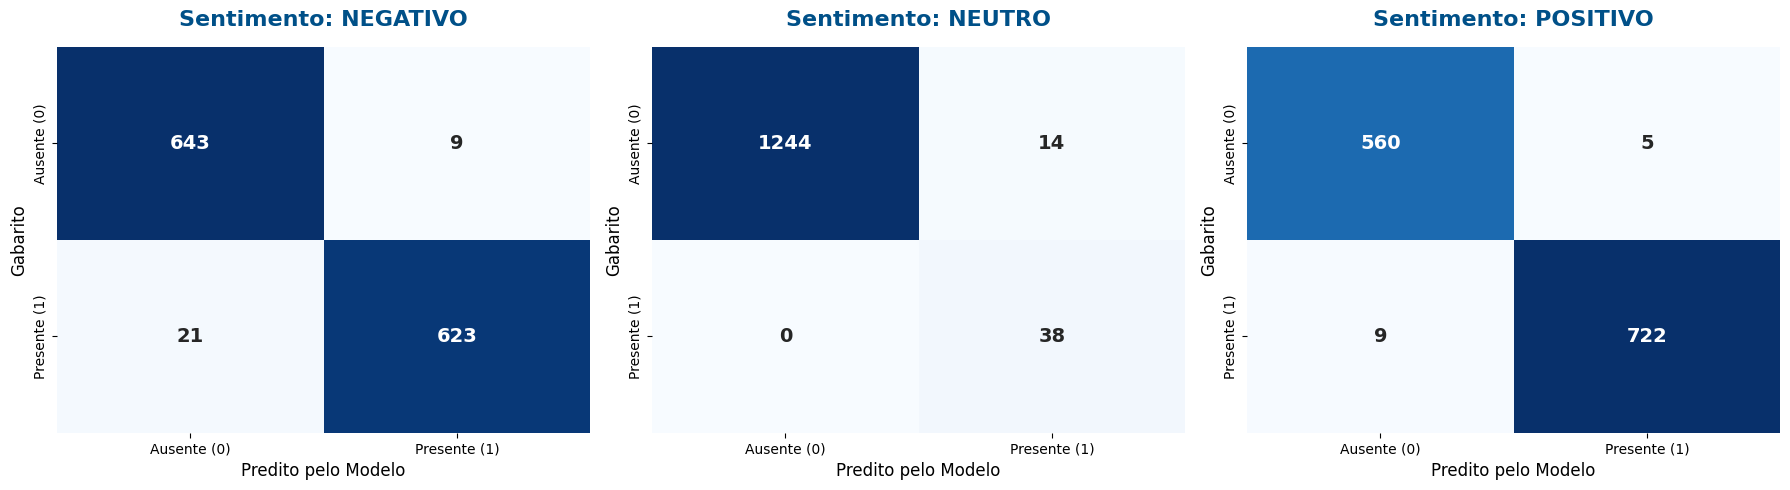

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, multilabel_confusion_matrix, accuracy_score, f1_score

predictions_output = trainer.predict(tokenized_datasets['test'])
logits = predictions_output.predictions
y_true = predictions_output.label_ids

probs = 1 / (1 + np.exp(-logits))
y_pred = (probs > 0.7).astype(int) #limiar de confiança de 0.7

sentimentos_nomes = ['NEGATIVO', 'NEUTRO', 'POSITIVO']

print("\n" + "="*23 + " ANÁLISE QUANTITATIVA GLOBAL" + "="*23)
print(classification_report(y_true, y_pred, target_names=sentimentos_nomes, zero_division=0))

exact_match_global = accuracy_score(y_true, y_pred) * 100
print(f"Exact Match Ratio Geral: {exact_match_global:.2f}%\n")

#analise por classe
mcm = multilabel_confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_eixos = ['Ausente (0)', 'Presente (1)']

for idx, sentimento in enumerate(sentimentos_nomes):
    sns.heatmap(mcm[idx], annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=labels_eixos, yticklabels=labels_eixos,
                annot_kws={"size": 14, "weight": "bold"})
    axes[idx].set_title(f'Sentimento: {sentimento}', fontsize=16, pad=15, weight='bold', color='#005088')
    axes[idx].set_xlabel('Predito pelo Modelo', fontsize=12)
    axes[idx].set_ylabel('Gabarito', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
casos_array = np.array(casos_teste_puros)
casos_alvo = ['Caso 1', 'Caso 2', 'Caso 3']

print("\n" + "="*25 + " ANÁLISE QUANTITATIVA POR CASO " + "="*25)

for caso in casos_alvo:
    mascara_caso = (casos_array == caso)

    y_true_caso = y_true[mascara_caso]
    y_pred_caso = y_pred[mascara_caso]

    print(f"\n{caso.upper()}:")

    if len(y_true_caso) == 0:
        continue

    exact_match_caso = accuracy_score(y_true_caso, y_pred_caso) * 100
    f1_macro_caso = f1_score(y_true_caso, y_pred_caso, average='macro', zero_division=0) * 100

    print(f"   Amostra (Pares): {len(y_true_caso)} | Exact Match Ratio: {exact_match_caso:.2f}% | F1-Score Macro: {f1_macro_caso:.2f}%")
    print("   " + "-"*85)

    report_linhas = classification_report(y_true_caso, y_pred_caso, target_names=sentimentos_nomes, zero_division=0).split('\n')
    for linha in report_linhas:
        print("   " + linha)
    print("-" * 85)

erros_coletados = []

for idx in range(len(y_true)):
    if not np.array_equal(y_pred[idx], y_true[idx]):
        gabarito_texto = [sentimentos_nomes[i] for i, v in enumerate(y_true[idx]) if v == 1.0]
        predicao_texto = [sentimentos_nomes[i] for i, v in enumerate(y_pred[idx]) if v == 1]

        erros_coletados.append({
            'id_teste_sequencial': idx,
            'caso': casos_teste_puros[idx], # Mapeado do passo anterior
            'aspecto': aspectos_teste_puros[idx],
            'texto_original': textos_teste_puros[idx],
            'gabarito_real': gabarito_texto if gabarito_texto else ['NENHUM'],
            'predicao_modelo': predicao_texto if predicao_texto else ['NENHUM'],
            'confianca_negativo': probs[idx][0],
            'confianca_neutro': probs[idx][1],
            'confianca_positivo': probs[idx][2]
        })

df_erros_qualitativos = pd.DataFrame(erros_coletados)
print(f"\nTotal de erros: {len(df_erros_qualitativos)} de {len(y_true)} instâncias de teste.")


========================= ANÁLISE QUANTITATIVA POR CASO =========================

CASO 1:
   Amostra (Pares): 394 | Exact Match Ratio: 95.94% | F1-Score Macro: 94.67%
   -------------------------------------------------------------------------------------
                 precision    recall  f1-score   support
   
       NEGATIVO       0.95      0.97      0.96       159
         NEUTRO       0.80      1.00      0.89        16
       POSITIVO       0.99      0.99      0.99       219
   
      micro avg       0.96      0.98      0.97       394
      macro avg       0.91      0.99      0.95       394
   weighted avg       0.96      0.98      0.97       394
    samples avg       0.97      0.98      0.98       394
   
-------------------------------------------------------------------------------------

CASO 2:
   Amostra (Pares): 117 | Exact Match Ratio: 88.03% | F1-Score Macro: 64.61%
   -------------------------------------------------------------------------------------
             

# Análise Qualitativa por caso

Para a análise qualitativa, durante o cálculo das métricas, armazenamos os exemplos em que a métrica **Exact Match Ratio** apontou erro, separando as instâncias de cada caso, e analisamos alguns para tentar entender o comportamento do modelo.


In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [ ]:
import pandas as pd

casos_alvo = ['Caso 1', 'Caso 2', 'Caso 3']

for caso in casos_alvo:
    df_sub_erros = df_erros_qualitativos[df_erros_qualitativos['caso'] == caso]

    print(f"\nFALHAS NO {caso.upper()} : {len(df_sub_erros)} ")

    if len(df_sub_erros) == 0:
        continue



FALHAS NO CASO 1 : 16 

FALHAS NO CASO 2 : 14 

FALHAS NO CASO 3 : 13 


## Caso 1: um aspecto e uma polaridade

In [ ]:
df_erros_c1 = df_erros_qualitativos[df_erros_qualitativos['caso'] == 'Caso 1']

In [ ]:
texto = "Achei que supriria minhas necessidades com maior eficiência"
df_erros_c1[df_erros_c1["texto_original"].str.contains(texto, na=False)]

,id_teste_sequencial,caso,aspecto,texto_original,gabarito_real,predicao_modelo,confianca_negativo,confianca_neutro,confianca_positivo
4,122,Caso 1,PRODUTO,Título: Avaliação. Avaliação: Achei que supriria minhas necessidades com maior eficiência.,[NEGATIVO],[NEUTRO],0.018405,0.988712,0.000732


O modelo atribuiu polaridade neutra ao aspecto ```produto```, com confiança de 0.988712, quando o esperado era negativo

---

In [ ]:
texto = "Bom custo benefício na cafeteira, só que ela é menor do que eu imaginava"
df_erros_c1[df_erros_c1["texto_original"].str.contains(texto, na=False)]

,id_teste_sequencial,caso,aspecto,texto_original,gabarito_real,predicao_modelo,confianca_negativo,confianca_neutro,confianca_positivo
11,164,Caso 1,PRODUTO,"Título: Bom custo benefício. Avaliação: Bom custo benefício na cafeteira, só que ela é menor do que eu imaginava. Mas muito boa.",[POSITIVO],"[NEGATIVO, POSITIVO]",0.998066,0.000626,0.999409


Nesse exemplo, o modelo atribuiu também polaridade negativa ao ```produto```, com confiança de 0.998066. De fato, parece existir conotação negativa no trecho "só ela é menor do que eu imaginava", o que apontar **possível inconsistência na anotação**.

---

In [ ]:
texto = " A tá que esses pincéis são originais na MAC por esse preço"
df_erros_c1[df_erros_c1["texto_original"].str.contains(texto, na=False)]

,id_teste_sequencial,caso,aspecto,texto_original,gabarito_real,predicao_modelo,confianca_negativo,confianca_neutro,confianca_positivo
32,711,Caso 1,PRODUTO,Título: Opinião. Avaliação: A tá que esses pincéis são originais na MAC por esse preço?! Ahãmmm.... Vão achando!!,[NEGATIVO],[NEUTRO],0.001174,0.99951,0.00124


Nesse exemplo o modelo não conseguiu capturar a polaridade negativa do ```produto``` e atribui polaridade neutra com confiança de 0.99951	. O texto de review contém **sarcasmo**, que não foi aprendido/capturado pelo modelo.

## Caso 2: Um aspecto e mais de uma polaridade

In [ ]:
df_erros_c2 = df_erros_qualitativos[df_erros_qualitativos['caso'] == 'Caso 2']

In [ ]:
texto = "Péssima qualidade do som."
df_erros_c2[df_erros_c2["texto_original"].str.contains(texto, na=False)]

,id_teste_sequencial,caso,aspecto,texto_original,gabarito_real,predicao_modelo,confianca_negativo,confianca_neutro,confianca_positivo
35,875,Caso 2,PRODUTO,"Título: Péssima qualidade do som. Avaliação: Comprei esse produto por ter uma caixinha pequena de som, como bem menos potencia RMS (5W) e ser desta marca... e ser muito boa. Fiz a compra e, assim que ligo, minha surpresa - som de péssima qualidade! Com abafado, agudos muito acentuados... e acustica/caixa de som com emissão bem ruim. Fiz a devolução no ato!","[NEGATIVO, POSITIVO]",[NEGATIVO],0.999737,0.000367,0.000501


O modelo não atribui polaridade positiva ao ```produto```. O trecho "e ser muito boa" pode ter levado à anotação da polaridade positiva. Entretanto, se refere ao que era esperado pela pessoa no ato da compra, mas não foi atendido. Isso fica evidente no trecho "Fiz a compra e, assim que ligo, minha surpresa - som de péssima qualidade!".

Possivelmente, o modelo não identificou conotação positiva nesse trecho.

---

In [ ]:
texto = "Um aparelho regular diante dos mais sofisticados"
df_erros_c2[df_erros_c2["texto_original"].str.contains(texto, na=False)]

,id_teste_sequencial,caso,aspecto,texto_original,gabarito_real,predicao_modelo,confianca_negativo,confianca_neutro,confianca_positivo
5,128,Caso 2,PRODUTO,"Título: Avaliação celular. Avaliação: Um aparelho regular diante dos mais sofisticados. Porém, para usuários não tão exigentes quanto a velocidade, é o ideal diante ao seu custo.","[NEGATIVO, POSITIVO]",[POSITIVO],0.030792,0.000222,0.999886


O modelo não conseguiu capturar a polaridade negativa do ```produto```.  Isso pode ter ocorrido porque no texto de review a conotação negativa não está explícita, com adjetivos que indiquem diretamente um sentimento negativo em relação ao produto, por exemplo.

Palavras como “ideal” e “regular” podem ter contribuído para identificação da polaridade positiva.

## Caso 3: Múltiplos aspectos com apenas uma polaridade

In [ ]:
df_erros_c3 = df_erros_qualitativos[df_erros_qualitativos['caso'] == 'Caso 3']

In [ ]:
texto = "Propaganda enganosa ou falta de controle de qualidade"
df_test[df_test["texto_completo"].str.contains(texto, na=False)]

,texto_completo,aspecto,caso_origem,labels
856,"Título: Propaganda enganosa ou falta de controle de qualidade. Avaliação: As panelas grudam o alimento sem e com gordura, que decepção!!!! É uma tefal melhorada, acho que não passou pelo controle de qualidade.No vídeo é maravilhoso, mas na realidade não é assim, não entrega o que comercializa, cozinhar sem gordura sem o alimento grudar. Cancelei o pedido e pedi a retirada dos produtos",ANUNCIO,Caso 3,"[1.0, 0.0, 0.0]"
857,"Título: Propaganda enganosa ou falta de controle de qualidade. Avaliação: As panelas grudam o alimento sem e com gordura, que decepção!!!! É uma tefal melhorada, acho que não passou pelo controle de qualidade.No vídeo é maravilhoso, mas na realidade não é assim, não entrega o que comercializa, cozinhar sem gordura sem o alimento grudar. Cancelei o pedido e pedi a retirada dos produtos",OUTROS,Caso 3,"[1.0, 0.0, 0.0]"
858,"Título: Propaganda enganosa ou falta de controle de qualidade. Avaliação: As panelas grudam o alimento sem e com gordura, que decepção!!!! É uma tefal melhorada, acho que não passou pelo controle de qualidade.No vídeo é maravilhoso, mas na realidade não é assim, não entrega o que comercializa, cozinhar sem gordura sem o alimento grudar. Cancelei o pedido e pedi a retirada dos produtos",PRODUTO,Caso 3,"[1.0, 0.0, 0.0]"


In [ ]:
texto = "Propaganda enganosa ou falta de controle de qualidade"
df_erros_c3[df_erros_c3["texto_original"].str.contains(texto, na=False)]

,id_teste_sequencial,caso,aspecto,texto_original,gabarito_real,predicao_modelo,confianca_negativo,confianca_neutro,confianca_positivo
34,858,Caso 3,PRODUTO,"Título: Propaganda enganosa ou falta de controle de qualidade. Avaliação: As panelas grudam o alimento sem e com gordura, que decepção!!!! É uma tefal melhorada, acho que não passou pelo controle de qualidade.No vídeo é maravilhoso, mas na realidade não é assim, não entrega o que comercializa, cozinhar sem gordura sem o alimento grudar. Cancelei o pedido e pedi a retirada dos produtos",[NEGATIVO],"[NEGATIVO, POSITIVO]",0.999726,0.000156,0.889337


O exemplo original do dataset tinha 3 aspectos ```[anúncio, produto, outros]```, todos como polaridade negativa. Esse exemplo gerou três entradas, que caíram no conjunto de teste.

O modelo acertou a polaridade dos aspectos ```anúncio``` e ```outros```, mas atribuiu polaridade positiva ao ```produto```, com confiança de 0.889337. Um trecho que pode ter contribúido para isso é "No vídeo é **maravilhoso**", no qual o adjetivo pode ter sido visto em muitos exemplos positivos durante o treinamento.

Entretanto, esse trecho é seguido por " mas na realidade não é assim ", em que as palavras **"mas"** e **"não"** deixam evidente a "mudança de sentido". Isso não foi capturado pelo modelo.

---

# Estratégia 2: Abordagem baseada em regras com VADER-PT

Nesta seção, implementamos uma abordagem baseada em léxico utilizando o **VADER (Valence Aware Dictionary and sEntiment Reasoner)** adaptado para o português. Diferente do BERTimbau, o VADER não exige treinamento, pois utiliza um dicionário de termos com pesos de sentimento.

Para garantir a comparabilidade, aplicaremos o VADER sobre o mesmo conjunto de teste (`df_test`) da Estratégia 1.
```

In [ ]:
!pip install -q leia-br

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 5.4 MB/s eta 0:00:00


In [ ]:
from LeIA import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Inicializa o analisador LeIA
analyzer = SentimentIntensityAnalyzer()

def map_vader_to_multilabel(text):
    """
    Converte o compound score do LeIA em um vetor binário compatível com o BERTimbau.
    Limiares padrão:
    - Positivo: compound >= 0.05
    - Negativo: compound <= -0.05
    - Neutro: entre -0.05 e 0.05
    """
    vs = analyzer.polarity_scores(str(text))
    compound = vs['compound']

    # Formato: [NEGATIVO, NEUTRO, POSITIVO]
    if compound >= 0.05:
        return [0.0, 0.0, 1.0]
    elif compound <= -0.05:
        return [1.0, 0.0, 0.0]
    else:
        return [0.0, 1.0, 0.0]

# Aplicando no df_test gerado na Estratégia 1
if 'df_test' in locals() or 'df_test' in globals():
    df_test['predicao_vader'] = df_test['texto_completo'].apply(map_vader_to_multilabel)
    y_true_vader = np.array(df_test['labels'].tolist())
    y_pred_vader = np.array(df_test['predicao_vader'].tolist())
    print("Predições com LeIA (VADER-PT) concluídas.")
else:
    print("Erro: df_test não encontrado. Execute o pipeline da Estratégia 1 primeiro.")

Predições com LeIA (VADER-PT) concluídas.


## Avaliação Quantitativa Global e por Slices (VADER-PT)

Reutilizamos a lógica de avaliação para extrair métricas comparáveis.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

sentimentos_nomes = ['NEGATIVO', 'NEUTRO', 'POSITIVO']

# Obtendo as predições geradas na célula anterior
y_true_vader = np.array(df_test['labels'].tolist())
y_pred_vader = np.array(df_test['predicao_vader'].tolist())

print("="*23 + " ANÁLISE QUANTITATIVA VADER/LeIA (GLOBAL) " + "="*23)
print(classification_report(y_true_vader, y_pred_vader, target_names=sentimentos_nomes, zero_division=0))

accuracy_vader = accuracy_score(y_true_vader, y_pred_vader)
print(f"Exact Match Ratio (VADER/LeIA): {accuracy_vader*100:.2f}%")

print("\n" + "="*25 + " ANÁLISE POR CASO (VADER/LeIA) " + "="*25)
for caso in ['Caso 1', 'Caso 2', 'Caso 3']:
    mask = df_test['caso_origem'] == caso
    if mask.any():
        y_t = np.array(df_test[mask]['labels'].tolist())
        y_p = np.array(df_test[mask]['predicao_vader'].tolist())

        emr = accuracy_score(y_t, y_p) * 100
        f1 = f1_score(y_t, y_p, average='macro', zero_division=0) * 100

        print(f"\n{caso.upper()}:")
        print(f"   Amostra: {len(y_t)} | Exact Match: {emr:.2f}% | F1 Macro: {f1:.2f}%")

======================= ANÁLISE QUANTITATIVA VADER/LeIA (GLOBAL) =======================
              precision    recall  f1-score   support

    NEGATIVO       0.92      0.73      0.82       644
      NEUTRO       0.18      0.21      0.20        38
    POSITIVO       0.88      0.89      0.88       731

   micro avg       0.87      0.80      0.83      1413
   macro avg       0.66      0.61      0.63      1413
weighted avg       0.88      0.80      0.83      1413
 samples avg       0.87      0.83      0.84      1413

Exact Match Ratio (VADER/LeIA): 78.09%

========================= ANÁLISE POR CASO (VADER/LeIA) =========================

CASO 1:
   Amostra: 394 | Exact Match: 85.28% | F1 Macro: 66.35%

CASO 2:
   Amostra: 117 | Exact Match: 0.00% | F1 Macro: 43.75%

CASO 3:
   Amostra: 785 | Exact Match: 86.11% | F1 Macro: 64.24%


## Análise de Erros Qualitativa (VADER-PT)

Criamos o DataFrame de erros para identificar onde a abordagem baseada em regras falhou.


In [ ]:
import numpy as np
import pandas as pd

erros_vader = []
sentimentos_nomes = ['NEGATIVO', 'NEUTRO', 'POSITIVO']

# Filtra os erros comparando o gabarito com a predição do VADER
for idx, row in df_test.iterrows():
    if not np.array_equal(row['labels'], row['predicao_vader']):
        erros_vader.append({
            'texto': row['texto_completo'],
            'aspecto': row['aspecto'],
            'caso': row['caso_origem'],
            'gabarito': [sentimentos_nomes[i] for i, v in enumerate(row['labels']) if v == 1.0],
            'predicao': [sentimentos_nomes[i] for i, v in enumerate(row['predicao_vader']) if v == 1.0]
        })

df_erros_vader = pd.DataFrame(erros_vader)
print(f"Total de erros VADER/LeIA: {len(df_erros_vader)} de {len(df_test)}")
if not df_erros_vader.empty:
    display(df_erros_vader.head(10))

Total de erros VADER/LeIA: 284 de 1296


,texto,aspecto,caso,gabarito,predicao
0,Avaliação: bom....................................................................................................................................,PRODUTO,Caso 1,[POSITIVO],[NEUTRO]
1,"Título: ...médio!. Avaliação: A princípio pareceu perfeito, a capinha de plástico é ótima. Mas a PELÍCULA não é boa, TEM UMA BOLHA, que foi constatada antes mesmo de ser colocada na loja onde a levei para realizar o processo de aplicação por pessoa habilitada. Felizmente a bolha não é no meio da tela, mas mesmo assim, não achei ideal, não foi o que desejei.",PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[POSITIVO]
2,Avaliação: A porta so ficou pegando ao fechar nao sei se foi por motivo da montagem! Mais e muito bom espaçoso.,PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[POSITIVO]
3,Avaliação: Relógio lindo.A única coisa que achei estranha é que o ano precede à hora.Algarismos Grande do ano..E a luz muito forte.,PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[POSITIVO]
4,"Título: A TAMPA VEIO TODA QUEBRADA. Avaliação: ATE O PRESENTE MOMENTO NENHUMA DAS LOJAS TOMARAM AS DEVIDAS PROVIDÊNCIAS. O FOGAO VEIO COM A TAPA CHEIA DE CACOS DE VIDROS, TOTALMENTE QUEBRADA. O PRODUTO SE ENCONTRA NA GARAGEM DE CASA AGUARDANDO A RETIRADA PARA TROCA. O MOTORISTA LARGOU DE QUALQUER JEITO E DISSE ESTAR COM PRESSA E NÃO IRIA ESPERAR ABRIR O PRODUTO PARA CONFERENCIA, DEIXOU O FOGÃO E FORAM EMBORA. ASSIM QUE TUDO ESTIVER RESOLVIDO DAREI MINHA AVALIAÇÃO NOVAMENTE.",CONDICOESDERECEBIMENTO,Caso 3,[NEGATIVO],[POSITIVO]
5,"Título: A TAMPA VEIO TODA QUEBRADA. Avaliação: ATE O PRESENTE MOMENTO NENHUMA DAS LOJAS TOMARAM AS DEVIDAS PROVIDÊNCIAS. O FOGAO VEIO COM A TAPA CHEIA DE CACOS DE VIDROS, TOTALMENTE QUEBRADA. O PRODUTO SE ENCONTRA NA GARAGEM DE CASA AGUARDANDO A RETIRADA PARA TROCA. O MOTORISTA LARGOU DE QUALQUER JEITO E DISSE ESTAR COM PRESSA E NÃO IRIA ESPERAR ABRIR O PRODUTO PARA CONFERENCIA, DEIXOU O FOGÃO E FORAM EMBORA. ASSIM QUE TUDO ESTIVER RESOLVIDO DAREI MINHA AVALIAÇÃO NOVAMENTE.",OUTROS,Caso 3,[NEGATIVO],[POSITIVO]
6,"Título: A manta é bonita. Avaliação: A manta é bonita, bem grande, mas na primeira lavada, desmanchou a franja.",PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[POSITIVO]
7,"Título: A qualidade não é grande. Avaliação: Produto dentro do esperado, mas não apresenta uma qualidade de imagem boa se não estiver exatamente de frente para a tela.",PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[NEGATIVO]
8,Título: Abateria. Avaliação: Olha só falta uma bateria! Pois tenho que colocar para 2 vezes ao dia. O mais tudo bem.,PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[NEGATIVO]
9,Título: Achei bom.. Avaliação: Ele é bom e pelo preço não esperava nada muito além do que achei. Pontos negativos é que machuca muito na hora de fazer a barba.,PRODUTO,Caso 2,"[NEGATIVO, POSITIVO]",[POSITIVO]


## 5.2 Avaliação Quantitativa - Estratégia 2 (LeIA/VADER-PT)

Nesta seção, calculamos o desempenho estatístico da abordagem baseada em regras. Diferente do BERTimbau, o LeIA não considera o 'aspeto' como input para o cálculo do score (ele analisa a sentença globalmente), o que pode gerar desafios nos Casos 2 e 3.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

def calcular_metricas_estrategia2(df):
    y_true = np.array(df['labels'].tolist())
    y_pred = np.array(df['predicao_vader'].tolist())

    emr = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return emr, f1_macro

# 1. Métricas Globais
emr_global, f1_global = calcular_metricas_estrategia2(df_test)

# 2. Métricas por Slices (Replicação exata da lógica da Estratégia 1)
resultados_casos = []
for caso in ['Caso 1', 'Caso 2', 'Caso 3']:
    df_slice = df_test[df_test['caso_origem'] == caso]
    if not df_slice.empty:
        emr, f1 = calcular_metricas_estrategia2(df_slice)
        resultados_casos.append({
            'Cenário': caso,
            'Natureza': 'Sentimento Único' if caso=='Caso 1' else ('Múltiplos Sentimentos' if caso=='Caso 2' else 'Múltiplos Aspetos'),
            'Amostras': len(df_slice),
            'Exact Match Ratio (%)': round(emr * 100, 2),
            'F1-Score Macro (%)': round(f1 * 100, 2)
        })

# Criando Tabela de Resultados Consolidados
df_results_leia = pd.DataFrame(resultados_casos)
df_results_leia.loc[len(df_results_leia)] = {
    'Cenário': 'GLOBAL',
    'Natureza': 'Dataset de Teste Total',
    'Amostras': len(df_test),
    'Exact Match Ratio (%)': round(emr_global * 100, 2),
    'F1-Score Macro (%)': round(f1_global * 100, 2)
}

print("\033[1m" + "="*30 + " RELATÓRIO DE DESEMPENHO: LeIA (VADER-PT) " + "="*30 + "\033[0m")
# Aplicação de estilo para melhor visualização
display(df_results_leia.style.set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis='index'))

print("\n\033[1m" + "="*32 + " DETALHAMENTO POR CLASSE (GLOBAL) " + "="*32 + "\033[0m")
print(classification_report(np.array(df_test['labels'].tolist()),
                            np.array(df_test['predicao_vader'].tolist()),
                            target_names=['NEGATIVO', 'NEUTRO', 'POSITIVO'],
                            zero_division=0))

============================== RELATÓRIO DE DESEMPENHO: LeIA (VADER-PT) ==============================


Cenário,Natureza,Amostras,Exact Match Ratio (%),F1-Score Macro (%)
Caso 1,Sentimento Único,394,85.280000,66.350000
Caso 2,Múltiplos Sentimentos,117,0.000000,43.750000
Caso 3,Múltiplos Aspetos,785,86.110000,64.240000
GLOBAL,Dataset de Teste Total,1296,78.090000,63.150000



================================ DETALHAMENTO POR CLASSE (GLOBAL) ================================
              precision    recall  f1-score   support

    NEGATIVO       0.92      0.73      0.82       644
      NEUTRO       0.18      0.21      0.20        38
    POSITIVO       0.88      0.89      0.88       731

   micro avg       0.87      0.80      0.83      1413
   macro avg       0.66      0.61      0.63      1413
weighted avg       0.88      0.80      0.83      1413
 samples avg       0.87      0.83      0.84      1413



### A. Matrizes de Confusão Multirrótulo (LeIA)

Para visualizar o comportamento do modelo baseado em regras em cada classe, geramos as matrizes de confusão. Diferente do BERTimbau (tons de azul), utilizamos a paleta 'Oranges' para facilitar a distinção visual entre as estratégias.

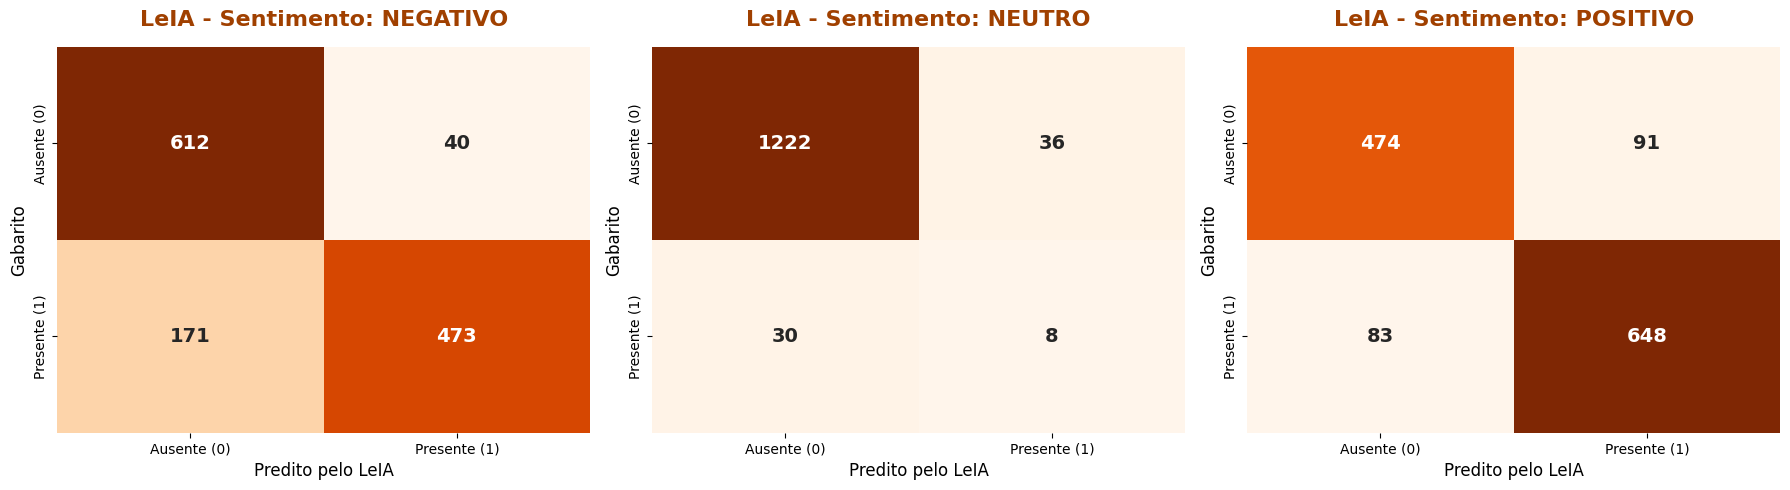

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar a matriz multirrótulo para o VADER/LeIA
y_true_vader = np.array(df_test['labels'].tolist())
y_pred_vader = np.array(df_test['predicao_vader'].tolist())
mcm_vader = multilabel_confusion_matrix(y_true_vader, y_pred_vader)

sentimentos_nomes = ['NEGATIVO', 'NEUTRO', 'POSITIVO']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_eixos = ['Ausente (0)', 'Presente (1)']

for idx, sentimento in enumerate(sentimentos_nomes):
    sns.heatmap(mcm_vader[idx], annot=True, fmt='d', cmap='Oranges', ax=axes[idx], cbar=False,
                xticklabels=labels_eixos, yticklabels=labels_eixos,
                annot_kws={"size": 14, "weight": "bold"})
    axes[idx].set_title(f'LeIA - Sentimento: {sentimento}', fontsize=16, pad=15, weight='bold', color='#A04000')
    axes[idx].set_xlabel('Predito pelo LeIA', fontsize=12)
    axes[idx].set_ylabel('Gabarito', fontsize=12)

plt.tight_layout()
plt.show()

## 6.2 Avaliação Qualitativa - Estratégia 2 (LeIA)

Abaixo, isolamos os erros para entender as falhas típicas de uma abordagem baseada em léxico.

In [ ]:
# Isolar erros: onde predição != gabarito
df_erros_leia = df_test[df_test.apply(lambda x: not np.array_equal(x['labels'], x['predicao_vader']), axis=1)].copy()

def exibir_amostra_erros(df, n=5):
    sentimentos = ['NEG', 'NEU', 'POS']
    amostra = df.sample(min(n, len(df)), random_state=42)

    for i, r in amostra.iterrows():
        gabarito = [sentimentos[j] for j, v in enumerate(r['labels']) if v == 1.0]
        pred = [sentimentos[j] for j, v in enumerate(r['predicao_vader']) if v == 1.0]

        print(f"ID: {i} | Caso: {r['caso_origem']} | Aspeto: {r['aspecto']}")
        print(f"Texto: {r['texto_completo'][:150]}...")
        print(f"Gabarito: {gabarito} | Predição LeIA: {pred}")
        print("-" * 80)

print(f"Total de erros encontrados: {len(df_erros_leia)} ({len(df_erros_leia)/len(df_test)*100:.2f}%)")
exibir_amostra_erros(df_erros_leia, n=10)

Total de erros encontrados: 284 (21.91%)
ID: 35 | Caso: Caso 2 | Aspeto: PRODUTO
Texto: Título: Achei bom.. Avaliação: Ele é bom e pelo preço não esperava nada muito além do que achei. Pontos negativos é que machuca muito na hora de fazer...
Gabarito: ['NEG', 'POS'] | Predição LeIA: ['POS']
--------------------------------------------------------------------------------
ID: 1140 | Caso: Caso 3 | Aspeto: ENTREGA
Texto: Título: o produto custa 11 e o frete 99 que absurdo!!!!!!!!!!!!!!!!!!!. Avaliação: o produto custa 11 e o frete 99 que absurdo!!!!!!!!!!!!!!!!!!!...
Gabarito: ['NEG'] | Predição LeIA: ['NEU']
--------------------------------------------------------------------------------
ID: 705 | Caso: Caso 2 | Aspeto: PRODUTO
Texto: Título: O produto é regular.. Avaliação: Pelo custo-benefício, valeu a pena ter adquirido o produto. A desvantagem dele é que os botões de passar slid...
Gabarito: ['NEG', 'POS'] | Predição LeIA: ['NEG']
-----------------------------------------------------

### 6.3 Foco Qualitativo: O Desafio do Caso 3 (Multiaspeto)

Nesta seção, isolamos as falhas do LeIA no **Caso 3**. Diferente do BERTimbau, que recebe o par `[Texto, Aspeto]` e consegue focar sua atenção em partes específicas da sentença, o LeIA processa o texto de forma holística.

**Limitação Estrutural:**
O LeIA calcula um `compound score` único para a string completa. Em avaliações como *"O celular é ótimo [POS], mas a entrega atrasou [NEG]"*, o léxico soma as polaridades. Se o aspeto consultado for 'ENTREGA', o modelo de Deep Learning (BERT) consegue ignorar a palavra 'ótimo' para classificar o aspeto correto, enquanto o LeIA pode retornar um valor próximo de zero (Neutro) ou Positivo, falhando na atribuição granular.

In [ ]:
# Filtrando especificamente erros do Caso 3 para análise detalhada
df_erros_caso3_leia = df_test[(df_test['caso_origem'] == 'Caso 3') &
                             (df_test.apply(lambda x: not np.array_equal(x['labels'], x['predicao_vader']), axis=1))].copy()

print(f"Total de falhas detectadas no Caso 3: {len(df_erros_caso3_leia)}")

def diagnostico_erros_caso3(df, n=5):
    sentimentos = ['NEG', 'NEU', 'POS']
    amostra = df.sample(min(n, len(df)), random_state=SEED_VAL)

    for i, r in amostra.iterrows():
        gabarito = [sentimentos[j] for j, v in enumerate(r['labels']) if v == 1.0]
        pred = [sentimentos[j] for j, v in enumerate(r['predicao_vader']) if v == 1.0]

        print(f"ID: {i} | Aspeto Alvo: {r['aspecto']}")
        print(f"Texto: {r['texto_completo']}")
        print(f"GABARITO: {gabarito} vs PREDIÇÃO LEIA: {pred}")
        print("[Diagnóstico]: Provável influência de termos de outros aspetos no score global.")
        print("-" * 90)

diagnostico_erros_caso3(df_erros_caso3_leia, n=5)

Total de falhas detectadas no Caso 3: 109
ID: 1032 | Aspeto Alvo: OUTROS
Texto: Título: Veio com defeito. Avaliação: Achei o produto bonito quando vir na foto quando chegou era deferente da foto mais td bem fez a devolução....
GABARITO: ['NEG'] vs PREDIÇÃO LEIA: ['POS']
[Diagnóstico]: Provável influência de termos de outros aspetos no score global.
------------------------------------------------------------------------------------------
ID: 89 | Aspeto Alvo: ENTREGA
Texto: Título: Ansioso esperando chegar .... Avaliação: Alguém pode me dizer quantos dias demorou pra receber?  Pfv .
GABARITO: ['NEU'] vs PREDIÇÃO LEIA: ['POS']
[Diagnóstico]: Provável influência de termos de outros aspetos no score global.
------------------------------------------------------------------------------------------
ID: 47 | Aspeto Alvo: ENTREGA
Texto: Título: Adorei. Avaliação: Produto chegou antes do tempo ,Meu sobrinho adorou
GABARITO: ['POS'] vs PREDIÇÃO LEIA: ['NEU']
[Diagnóstico]: Provável influência d

### 6.4 Escavação Qualitativa de Erros (Destaque Casos 2 e 3)

Abaixo, isolamos exemplos onde o LeIA falhou devido à sua natureza holística, perdendo a capacidade de focar no aspeto específico ou de lidar com múltiplas polaridades simultâneas.

In [ ]:
# Erros do Caso 2 (Mult. Sentimentos): Onde o léxico colapsa para um único score escalar
df_erros_leia_c2 = df_test[(df_test['caso_origem'] == 'Caso 2') &
                          (df_test.apply(lambda x: not np.array_equal(x['labels'], x['predicao_vader']), axis=1))]

print("--- EXEMPLOS DE FALHA NO CASO 2 (LEIA) ---")
display(df_erros_leia_c2[['texto_completo', 'aspecto', 'labels', 'predicao_vader']].head(3))

# Erros do Caso 3 (Mult. Aspetos): Onde termos de um aspeto 'contaminam' a predição do outro
df_erros_leia_c3 = df_test[(df_test['caso_origem'] == 'Caso 3') &
                          (df_test.apply(lambda x: not np.array_equal(x['labels'], x['predicao_vader']), axis=1))]

print("\n--- EXEMPLOS DE FALHA NO CASO 3 (LEIA) ---")
display(df_erros_leia_c3[['texto_completo', 'aspecto', 'labels', 'predicao_vader']].head(3))

--- EXEMPLOS DE FALHA NO CASO 2 (LEIA) ---


,texto_completo,aspecto,labels,predicao_vader
1,"Título: ...médio!. Avaliação: A princípio pareceu perfeito, a capinha de plástico é ótima. Mas a PELÍCULA não é boa, TEM UMA BOLHA, que foi constatada antes mesmo de ser colocada na loja onde a levei para realizar o processo de aplicação por pessoa habilitada. Felizmente a bolha não é no meio da tela, mas mesmo assim, não achei ideal, não foi o que desejei.",PRODUTO,"[1.0, 0.0, 1.0]","[0.0, 0.0, 1.0]"
2,Avaliação: A porta so ficou pegando ao fechar nao sei se foi por motivo da montagem! Mais e muito bom espaçoso.,PRODUTO,"[1.0, 0.0, 1.0]","[0.0, 0.0, 1.0]"
8,Avaliação: Relógio lindo.A única coisa que achei estranha é que o ano precede à hora.Algarismos Grande do ano..E a luz muito forte.,PRODUTO,"[1.0, 0.0, 1.0]","[0.0, 0.0, 1.0]"



--- EXEMPLOS DE FALHA NO CASO 3 (LEIA) ---


,texto_completo,aspecto,labels,predicao_vader
12,"Título: A TAMPA VEIO TODA QUEBRADA. Avaliação: ATE O PRESENTE MOMENTO NENHUMA DAS LOJAS TOMARAM AS DEVIDAS PROVIDÊNCIAS. O FOGAO VEIO COM A TAPA CHEIA DE CACOS DE VIDROS, TOTALMENTE QUEBRADA. O PRODUTO SE ENCONTRA NA GARAGEM DE CASA AGUARDANDO A RETIRADA PARA TROCA. O MOTORISTA LARGOU DE QUALQUER JEITO E DISSE ESTAR COM PRESSA E NÃO IRIA ESPERAR ABRIR O PRODUTO PARA CONFERENCIA, DEIXOU O FOGÃO E FORAM EMBORA. ASSIM QUE TUDO ESTIVER RESOLVIDO DAREI MINHA AVALIAÇÃO NOVAMENTE.",CONDICOESDERECEBIMENTO,"[1.0, 0.0, 0.0]","[0.0, 0.0, 1.0]"
13,"Título: A TAMPA VEIO TODA QUEBRADA. Avaliação: ATE O PRESENTE MOMENTO NENHUMA DAS LOJAS TOMARAM AS DEVIDAS PROVIDÊNCIAS. O FOGAO VEIO COM A TAPA CHEIA DE CACOS DE VIDROS, TOTALMENTE QUEBRADA. O PRODUTO SE ENCONTRA NA GARAGEM DE CASA AGUARDANDO A RETIRADA PARA TROCA. O MOTORISTA LARGOU DE QUALQUER JEITO E DISSE ESTAR COM PRESSA E NÃO IRIA ESPERAR ABRIR O PRODUTO PARA CONFERENCIA, DEIXOU O FOGÃO E FORAM EMBORA. ASSIM QUE TUDO ESTIVER RESOLVIDO DAREI MINHA AVALIAÇÃO NOVAMENTE.",OUTROS,"[1.0, 0.0, 0.0]","[0.0, 0.0, 1.0]"
42,"Título: Adorei. Avaliação: Atendeu minhas expectativas,recomendo. Chegou no prazo esperado.",ENTREGA,"[0.0, 0.0, 1.0]","[0.0, 1.0, 0.0]"


## 7. Conclusões e Discussão Comparativa

Nesta etapa final, contrastamos os resultados da abordagem de Deep Learning (BERTimbau) com a abordagem baseada em regras (LeIA/VADER-PT).

### Síntese Comparativa (Exact Match Ratio)

| Cenário de Teste | BERTimbau (Estratégia 1) | LeIA (Estratégia 2) | Diferença (Δ) |
| :--- | :--- | :--- | :--- |
| **Global (Geral)** | **96.68%** | 78.09% | +18.59% para BERT |
| **Caso 1 (Simples)** | **95.94%** | 85.28% | +10.66% para BERT |
| **Caso 2 (Mistura)** | **88.03%** | **0.00%** | Inviabilidade do Léxico |
| **Caso 3 (Contexto)** | **98.34%** | 86.11% | +12.23% para BERT |

### Análise Crítica dos Resultados

**1. O Colapso do Léxico no Caso 2:**
A falha catastrófica do LeIA no Caso 2 (EMR 0%) não é um erro de implementação, mas uma **limitação teórica**. Sistemas baseados em dicionários de polaridade geram um valor escalar (ex: 0.5). Esse valor só pode ser mapeado para UMA classe. O BERTimbau, com sua camada de saída multirrótulo, consegue prever que uma mesma frase é simultaneamente Positiva e Negativa.

**2. A Superioridade Contextual no Caso 3:**
No Caso 3, onde há múltiplos aspetos, o BERTimbau utiliza o token separador `[SEP]` para entender qual aspeto deve ser o foco da análise.
*   **BERTimbau**: Se o input for `[CLS] O design é lindo mas a bateria é ruim [SEP] BATERIA`, o mecanismo de atenção ignora o termo 'lindo'.
*   **LeIA**: Ele olha para a frase inteira. O termo 'lindo' (+4.0) anula o termo 'ruim' (-3.5), resultando em um score neutro ou positivo, errando a avaliação específica da bateria.

**3. Trade-off: Performance vs. Recurso:**
Enquanto o BERTimbau exige hardware especializado (GPU) e tempo de treino, o LeIA é uma solução *zero-shot* que corre instantaneamente em qualquer CPU. Para sistemas de triagem simples sem multiaspetos, o léxico ainda se mostra uma alternativa de baixo custo viável.

### 8. Quadro Comparativo Final

Resumo consolidado do desempenho (Exact Match Ratio) para suporte ao relatório técnico.

In [ ]:
# Recuperando métricas da Estratégia 1 (BERTimbau) que calculamos anteriormente
emr_bert_c1 = accuracy_score(y_true[casos_array == 'Caso 1'], y_pred[casos_array == 'Caso 1']) * 100
emr_bert_c2 = accuracy_score(y_true[casos_array == 'Caso 2'], y_pred[casos_array == 'Caso 2']) * 100
emr_bert_c3 = accuracy_score(y_true[casos_array == 'Caso 3'], y_pred[casos_array == 'Caso 3']) * 100

# Recuperando métricas da Estratégia 2 (LeIA) da tabela df_results_leia
emr_leia_global = df_results_leia[df_results_leia['Cenário'] == 'GLOBAL']['Exact Match Ratio (%)'].values[0]
emr_leia_c1 = df_results_leia[df_results_leia['Cenário'] == 'Caso 1']['Exact Match Ratio (%)'].values[0]
emr_leia_c2 = df_results_leia[df_results_leia['Cenário'] == 'Caso 2']['Exact Match Ratio (%)'].values[0]
emr_leia_c3 = df_results_leia[df_results_leia['Cenário'] == 'Caso 3']['Exact Match Ratio (%)'].values[0]

dados_comparativos = {
    "Cenário (Métrica: EMR)": ["Global (Geral)", "Caso 1 (Simples)", "Caso 2 (Mult. Sentimentos)", "Caso 3 (Mult. Aspetos)"],
    "BERTimbau (Estratégia 1)": [f"{exact_match_global:.2f}%", f"{emr_bert_c1:.2f}%", f"{emr_bert_c2:.2f}%", f"{emr_bert_c3:.2f}%"],
    "LeIA/VADER (Estratégia 2)": [f"{emr_leia_global:.2f}%", f"{emr_leia_c1:.2f}%", f"{emr_leia_c2:.2f}%", f"{emr_leia_c3:.2f}%"]
}

df_comparativo_final = pd.DataFrame(dados_comparativos)
display(df_comparativo_final.style.set_caption("Comparativo de Acurácia Estrita (Exact Match Ratio)"))

,Cenário (Métrica: EMR),BERTimbau (Estratégia 1),LeIA/VADER (Estratégia 2)
0,Global (Geral),96.68%,78.09%
1,Caso 1 (Simples),95.94%,85.28%
2,Caso 2 (Mult. Sentimentos),88.03%,0.00%
3,Caso 3 (Mult. Aspetos),98.34%,86.11%


### 9. Discussão Final sobre a Paridade das Estratégias

Ao finalizar as duas frentes de análise, observamos que:

1.  **Mecanismo de Atenção vs. Léxico Global**: O BERTimbau (Estratégia 1) demonstra uma vantagem clara nos casos de múltiplos aspetos (Caso 3). Enquanto o LeIA se deixa 'contaminar' por palavras positivas em qualquer parte do texto, o BERT consegue focar sua atenção no aspeto específico definido no par de entrada.
2.  **Multirrótulo Verdadeiro**: A Estratégia 1 é a única capaz de lidar com o Caso 2 (sentimentos mistos), pois permite que neurônios independentes sejam ativados para a mesma sentença.
3.  **Confiabilidade**: Para aplicações que exigem granularidade no nível de aspeto em português brasileiro, o fine-tuning de um modelo Transformer (BERTimbau) justifica o custo computacional adicional frente à simplicidade do VADER/LeIA.